In [1]:
import sys
sys.path.append('../../../src')

import os
from PIL import Image, ImageFont, ImageChops
from PIL.Image import Resampling
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from modules.palette_generation import get_asciis
from modules.img_arr_ops import map_img_arr
from modules.presentation import render_symbols_img
from modules.img2chars_1d_bin import Img2Chars1dBin

SYMBOLS = get_asciis()
FONT = ImageFont.truetype("../../../fonts/CascadiaMono.ttf", 11)
IMG_SET_PATH = "../../../imgs/BSDS500"
IMG_PATHS = os.listdir(IMG_SET_PATH)

{'win_width': 500}
0.23535954443046248 0.8717513639998522 0.5965025952412428 0.0986988432424187
{'win_width': 400}
0.25225367457363057 0.8637475298277937 0.5895690196561004 0.10005738553378767
{'win_width': 300}
0.24825903418536732 0.8705559028813564 0.5988838742408836 0.09226354164904732
{'win_width': 200}
0.27167288233808307 0.8671272702058848 0.6108071681949636 0.08609281570170275
{'win_width': 100}
0.30629292124619223 0.8584679744657755 0.6199162089649171 0.07979894237475157
{'win_width': 75}
0.30998821378150676 0.8614853530741381 0.6165403880473698 0.08289182568647972
{'win_width': 50}
0.35455111727789024 0.8638587756784568 0.6265977362993306 0.07796484993773065
{'win_width': 25}
0.3660793368324978 0.866941479475839 0.6348689301133502 0.07474305841386346
{'win_width': 15}
0.3618728467546499 0.867889761457656 0.6383384051027811 0.07331894711014655
{'win_width': 5}
0.38182250419743546 0.87504764459135 0.6575304750007332 0.07218391585444714
{'win_width': 3}
0.39247896774010016 0.8880

C:\Users\wojte\AppData\Local\Temp\ipykernel_17032\1659632356.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores, labels=[param['win_width'] for param in params_space])


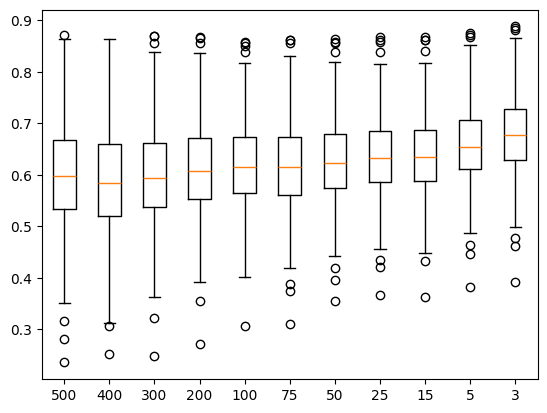

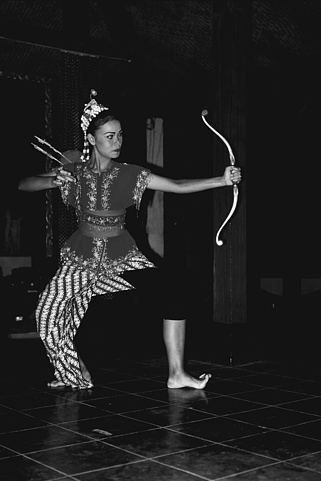

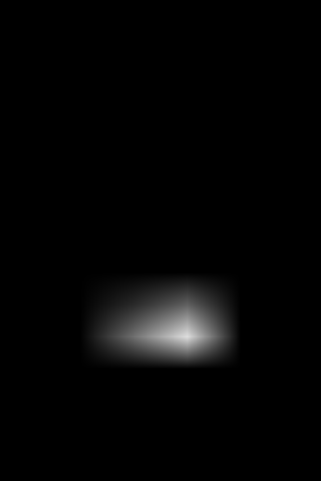

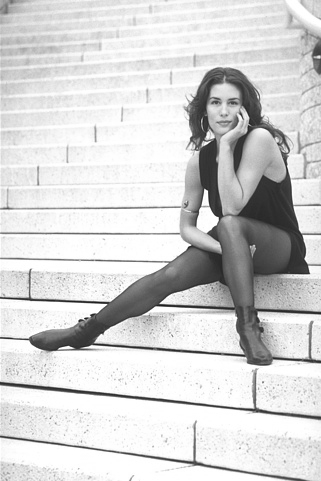

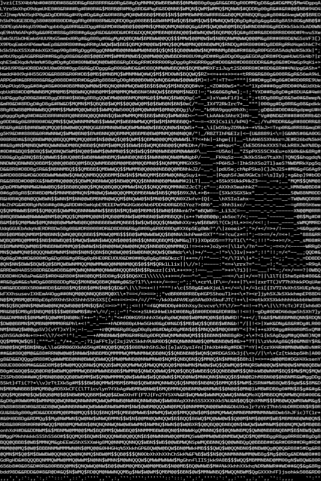

In [13]:
# windows width

params_space = [
    {'win_width': w} for w in range(500, 100, -100)
]
params_space += [
    {'win_width': w} for w in range(100, 25, -25)
]
params_space += [
    {'win_width': w} for w in range(25, 5, -10)
]
params_space += [
    {'win_width': w} for w in range(5, 2, -2)
]

converter = Img2Chars1dBin(symbols=SYMBOLS, font=FONT)

similarity_scores = []
best_worst = None
worst_best = None
for params in params_space:
    print(params)
    sim_scores_for_param = []
    best = None
    worst = None
    for img_path in IMG_PATHS:
        img = Image.open(os.path.join(IMG_SET_PATH, img_path))
        prep_img = img.convert("L")
        
        img_arr = np.array(img)
        res_arr = map_img_arr(
            img_arr,
            width=params['win_width'],
            height=params['win_width']*2,
            callback=lambda tile: converter.tile2symbol(tile))
        res_img = render_symbols_img(res_arr, FONT).convert("L")
        
        res_img = res_img.resize(prep_img.size, resample=Resampling.BILINEAR)
        sim = 1 - np.mean(ImageChops.difference(prep_img, res_img)) / 255
        sim_scores_for_param.append(sim)

        if not best or best[-1] < sim:
            best = (prep_img, res_img, sim)
        if not worst or worst[-1] > sim:
            worst = (prep_img, res_img, sim)

    mean_sim = np.mean(sim_scores_for_param)
    if not best_worst or best_worst[-1] < mean_sim:
        best_worst = (params, worst, mean_sim)
    if not worst_best or worst_best[-1] > mean_sim:
        worst_best = (params, best, mean_sim)

    print(min(sim_scores_for_param), max(sim_scores_for_param),
          np.mean(sim_scores_for_param), np.std(sim_scores_for_param))
    similarity_scores.append(sim_scores_for_param)

plt.boxplot(similarity_scores, labels=[param['win_width'] for param in params_space])
plt.show()

display(worst_best[1][0])
display(worst_best[1][1])
display(best_worst[1][0])
display(best_worst[1][1])